In [9]:
import os
os.chdir("/scale/user/mtannaou/alternance")
idx = 0
os.getcwd()

'/scale/user/mtannaou/alternance'

In [10]:
import pandas as pd
import src.IR_to_SAR.data_preparation.distribution_data_visualisation as datavis
from importlib import reload
reload(datavis)
from src.IR_to_SAR.data_preparation.distribution_data_visualisation import plot_ir, plot_sar, plot_mw
sargeo_tcprimed = pd.read_csv("excels/colocates_sargeo_primed_180min_v1.csv")
sargeo_tcva = pd.read_csv("src/IR_to_SAR/ML_IR_SAR/csv_data/TCVA_matched_with_SARGEO_v3_split_by_year.csv")
sargeo_tcprimed = sargeo_tcprimed[sargeo_tcprimed["count"]!=0]


diffs = []
for i, row in sargeo_tcprimed.iterrows():
    diff_liste = row["diff_time"].split("[")[-1].split("]")[0].split(",")
    for diff in diff_liste:
        diffs.append(int(float(diff.strip().strip("'").strip("'"))))
    
    path_sargeo = row["path_sargeo"]
    match = sargeo_tcva[sargeo_tcva["file"]==path_sargeo]
    if len(match) == 1 :  # pas de colocs >1
        sargeo_tcprimed.loc[i,"sar_aeqd_path"] = match["sar_aeqd_path"].iloc[0]
ir_mw_sar = sargeo_tcprimed.dropna(inplace=False)

In [11]:
import ast
import pandas as pd

def to_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or str(x).strip() == "[]":
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        return [x]

cols_to_explode = ["date_tcprimed", "path_tcprimed", "diff_time"]

for col in cols_to_explode:
    ir_mw_sar[col] = ir_mw_sar[col].apply(to_list)

ir_mw_sar = ir_mw_sar.explode(cols_to_explode, ignore_index=True)
len(ir_mw_sar)

/tmp/ipykernel_1522856/4003559644.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ir_mw_sar[col] = ir_mw_sar[col].apply(to_list)


1918

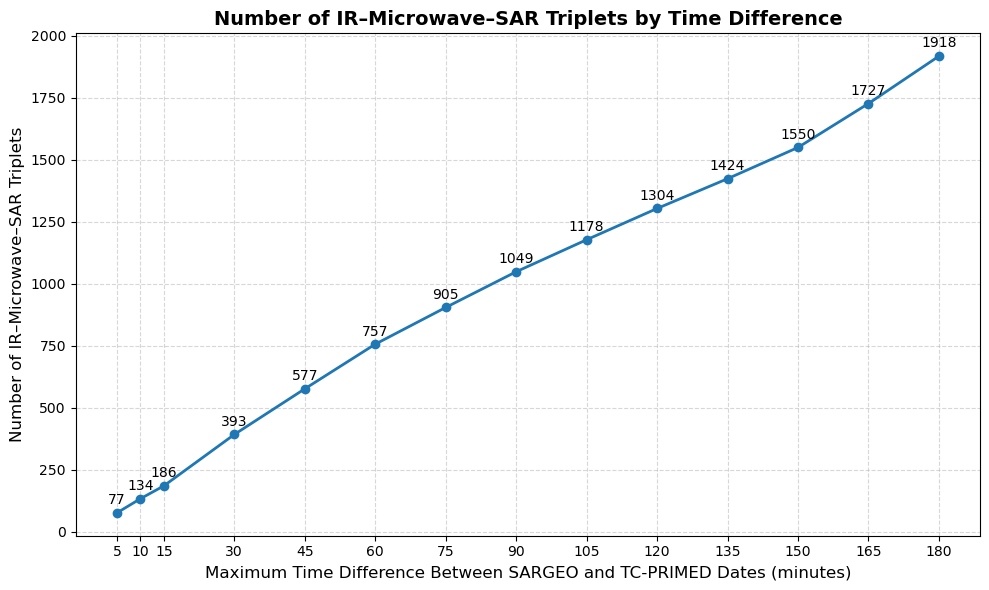

In [12]:
import matplotlib.pyplot as plt

# Time difference thresholds in minutes
time_diff_minutes = [5, 10, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]

# Number of IR–Microwave–SAR triplets
triplet_counts = [77, 134, 186, 393, 577, 757, 905, 1049, 1178, 1304, 1424, 1550, 1727, 1918]

plt.figure(figsize=(10, 6))

plt.plot(time_diff_minutes, triplet_counts, marker="o", linewidth=2)

for x, y in zip(time_diff_minutes, triplet_counts):
    plt.text(x, y + 35, str(y), ha="center", fontsize=10)

plt.title("Number of IR–Microwave–SAR Triplets by Time Difference", fontsize=14, fontweight="bold")
plt.xlabel("Maximum Time Difference Between SARGEO and TC-PRIMED Dates (minutes)", fontsize=12)
plt.ylabel("Number of IR–Microwave–SAR Triplets", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(time_diff_minutes)
plt.tight_layout()

plt.show()

In [13]:
tcprimed_jumeau_path = "/scale/project/ifremer-isi-jumeaunumerique/TC_PRIMED_DATASET/v01r01"
sargeo_jumeau_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v00r00/cyclobs"
for i , row in ir_mw_sar.iterrows():
    cyclone_id = row["cyclone_id"]
    ir_mw_sar.loc[i,"year"] = cyclone_id[-4:]
    year = cyclone_id[-4:]
    ir_mw_sar.loc[i,"bassin"] = str(cyclone_id[:2]).upper()
    bassin = str(cyclone_id[:2]).upper()
    ir_mw_sar.loc[i,"numero"] = cyclone_id[2:4]
    numero = cyclone_id[2:4]
    path_sargeo = row["path_sargeo"]
    path_tcprimed = row["path_tcprimed"]
    tcprimed_subfolder = (
                            "preliminary"
                            if (year == 2025) or ((year == 2024) and (bassin in ["AL", "EP"]))
                            else "final"
                        )
    path_tcprimed_full = os.path.join(tcprimed_jumeau_path,tcprimed_subfolder,str(year),bassin,numero,path_tcprimed)
    path_sargeo_full = os.path.join(sargeo_jumeau_path,cyclone_id,"IRWIN",path_sargeo)
    ir_mw_sar.loc[i,"path_sargeo"] = path_sargeo_full
    ir_mw_sar.loc[i,"path_tcprimed"] = path_tcprimed_full
ir_mw_sar.head()

,cyclone_id,count,date_sargeo,date_tcprimed,diff_time,path_sargeo,path_tcprimed,sar_aeqd_path,year,bassin,numero
0,al102019,2,2019-09-20T22:19:52.000,2019-09-21T01:08:58.000,10146.0,/scale/project/ifremer-isi-jumeaunumerique/SAR...,/scale/project/ifremer-isi-jumeaunumerique/TC_...,/scale/user/mtannaou/alternance/donnees_sar_ae...,2019,AL,10
1,al102019,2,2019-09-20T22:19:52.000,2019-09-20T20:59:30.000,4822.0,/scale/project/ifremer-isi-jumeaunumerique/SAR...,/scale/project/ifremer-isi-jumeaunumerique/TC_...,/scale/user/mtannaou/alternance/donnees_sar_ae...,2019,AL,10
2,ep192022,2,2022-10-22T12:47:42.000,2022-10-22T11:49:07.000,3515.0,/scale/project/ifremer-isi-jumeaunumerique/SAR...,/scale/project/ifremer-isi-jumeaunumerique/TC_...,/scale/user/mtannaou/alternance/donnees_sar_ae...,2022,EP,19
3,ep192022,2,2022-10-22T12:47:42.000,2022-10-22T12:24:29.000,1393.0,/scale/project/ifremer-isi-jumeaunumerique/SAR...,/scale/project/ifremer-isi-jumeaunumerique/TC_...,/scale/user/mtannaou/alternance/donnees_sar_ae...,2022,EP,19
4,ep122021,1,2021-08-18T14:39:06.000,2021-08-18T13:01:07.000,5879.0,/scale/project/ifremer-isi-jumeaunumerique/SAR...,/scale/project/ifremer-isi-jumeaunumerique/TC_...,/scale/user/mtannaou/alternance/donnees_sar_ae...,2021,EP,12


/tmp/ipykernel_1522856/1734421989.py:8: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ir = xr.open_dataset(path_sargeo)["IRWIN"]


Text(0.5, 1.0, 'IR Tcprimed')

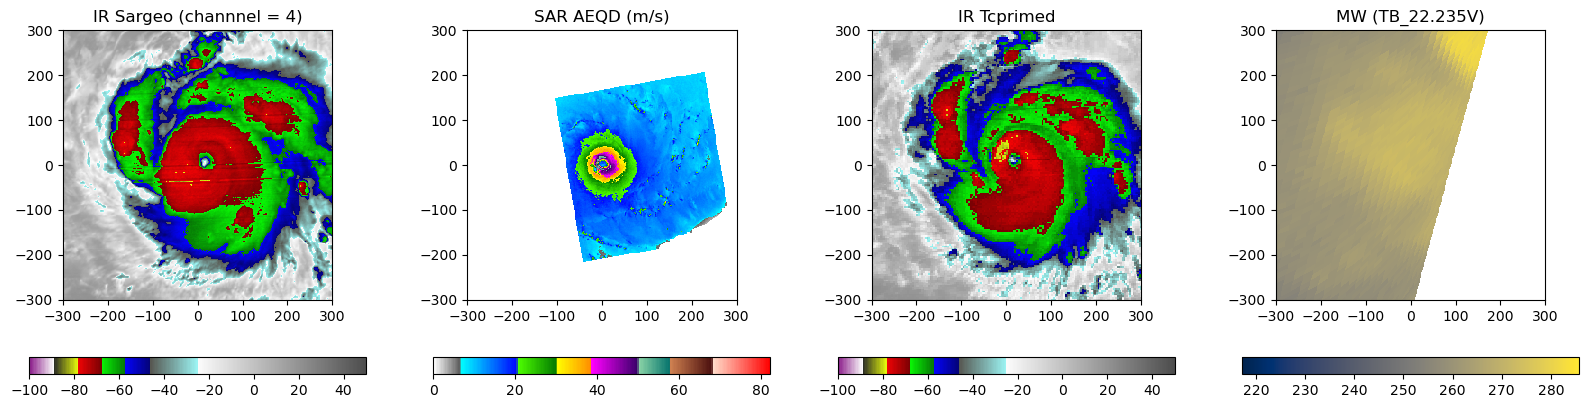

In [16]:
import xarray as xr
idx +=1
row_example = ir_mw_sar.iloc[idx]
path_sargeo = row_example["path_sargeo"]
path_sar = row_example["sar_aeqd_path"]
path_tcprimed = row_example["path_tcprimed"]
sar = xr.open_dataset(path_sar)["owiWindSpeed"].values.squeeze()
ir = xr.open_dataset(path_sargeo)["IRWIN"]
fig, axes = plt.subplots(1,4,figsize=(20,5))
plot_ir(ir[4].to_numpy()[1001//2-301//2:1001//2+301//2,1001//2-301//2:1001//2+301//2]-273.15,ax=axes[0],fig=fig);axes[0].set_title("IR Sargeo (channnel = 4)")
plot_sar(sar,ax=axes[1],fig=fig,title="SAR AEQD (m/s)")
ds = xr.open_dataset(path_tcprimed,group="passive_microwave/S1")
ds_ir_tcprimed =  xr.open_dataset(path_tcprimed,group="infrared")
channel_mw = list(ds.data_vars)[-1]
plot_mw(ds[channel_mw],ax=axes[-1],fig=fig,x=ds["x"].values,y=ds["y"].values);axes[-1].set_title(f"MW ({channel_mw})")
plot_ir(ds_ir_tcprimed["IRWIN"].values-273.15,x=ds_ir_tcprimed["x"].values,y=ds_ir_tcprimed["y"].values,ax=axes[2],fig=fig);
axes[2].set_title("IR Tcprimed")


In [17]:
ir_mw_sar.to_csv("src/IR_to_SAR/ML_IR_SAR/csv_data/sargeo_tcprimed_tcva.csv")